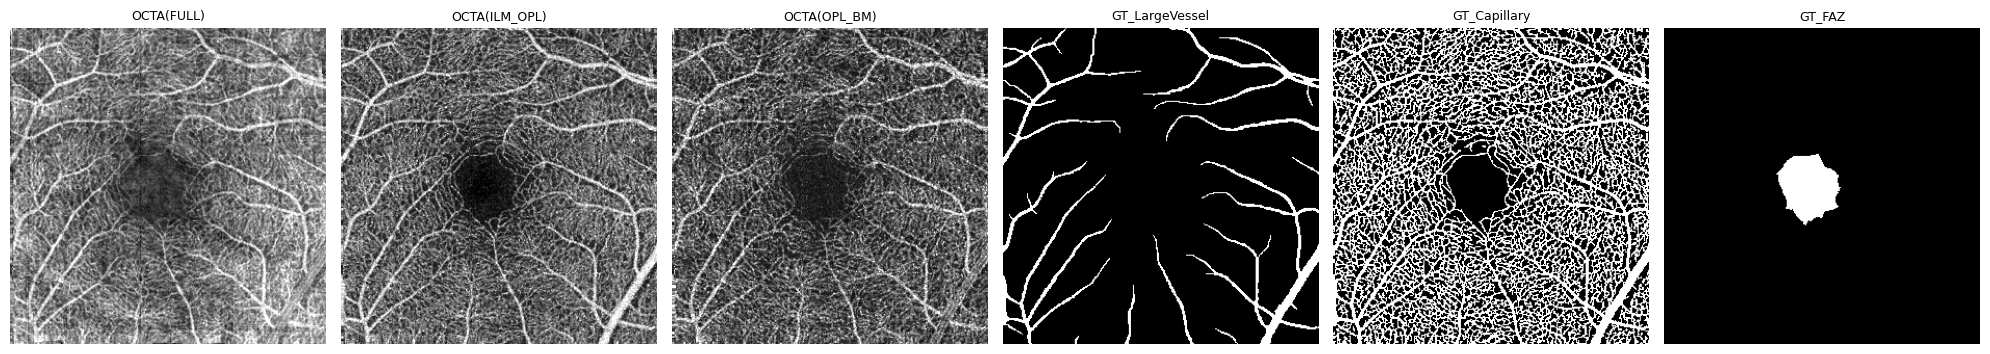

OCTA(FULL)            shape=(304, 304)  density=1.0000  min=0  max=255
OCTA(ILM_OPL)         shape=(304, 304)  density=0.9990  min=0  max=255
OCTA(OPL_BM)          shape=(304, 304)  density=1.0000  min=0  max=255
GT_LargeVessel        shape=(304, 304)  density=0.0826  min=0  max=255
GT_Capillary          shape=(304, 304)  density=0.4746  min=0  max=255
GT_FAZ                shape=(304, 304)  density=0.0303  min=0  max=255


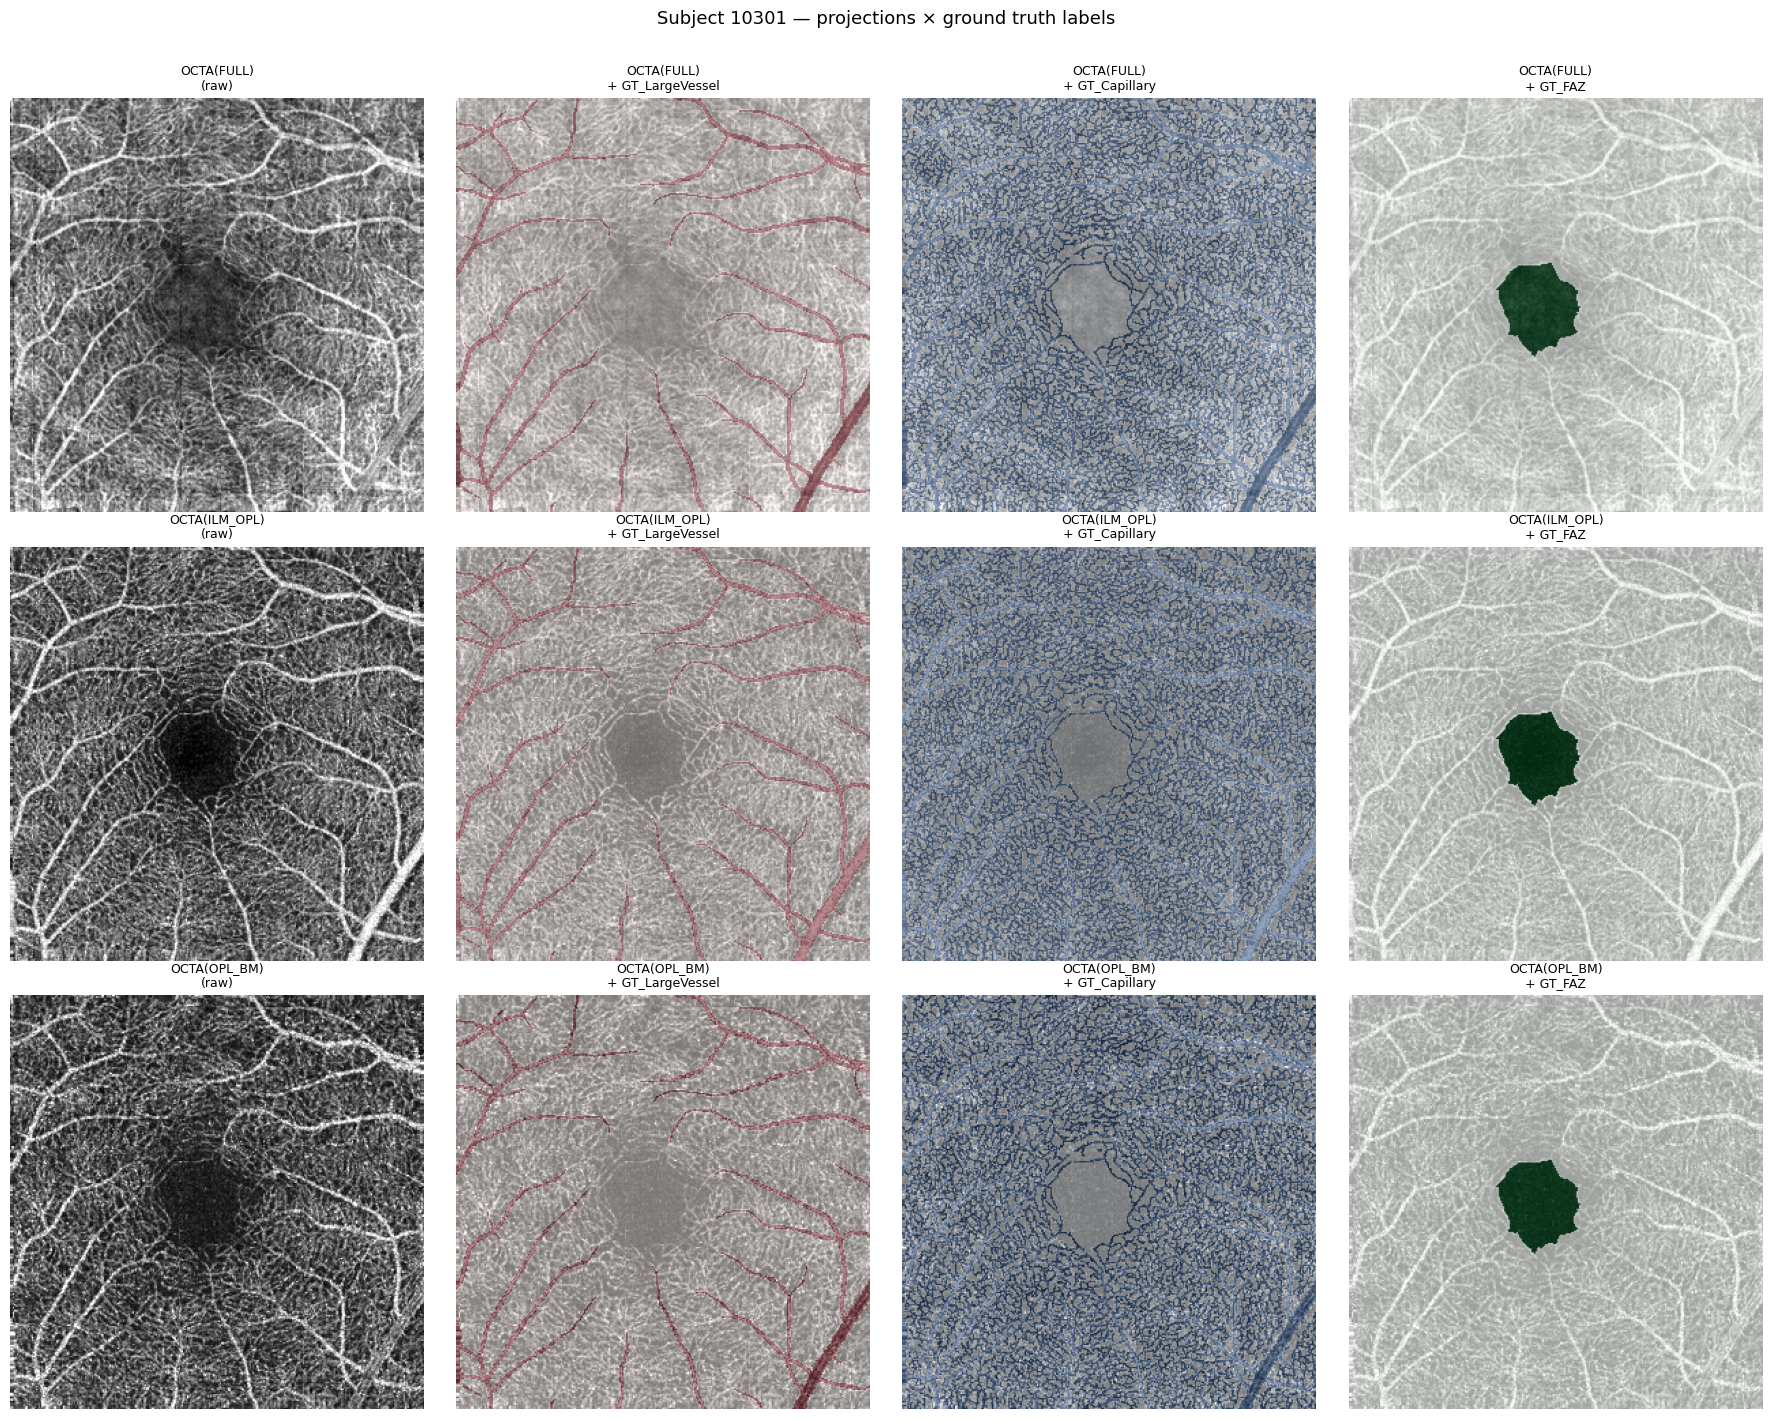

saved.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/OCTA_500")
PROJ = BASE / "OCTA_3mm/Projection Maps"
LABEL = BASE / "Label/Label"
subj = "10301"

# Load all projection types
projs = {
    "OCTA(FULL)":    cv2.imread(str(PROJ / f"OCTA(FULL)/{subj}.bmp"), cv2.IMREAD_GRAYSCALE),
    "OCTA(ILM_OPL)": cv2.imread(str(PROJ / f"OCTA(ILM_OPL)/{subj}.bmp"), cv2.IMREAD_GRAYSCALE),
    "OCTA(OPL_BM)":  cv2.imread(str(PROJ / f"OCTA(OPL_BM)/{subj}.bmp"), cv2.IMREAD_GRAYSCALE),
}

# Load all 2D label types
labels = {
    "GT_LargeVessel": cv2.imread(str(LABEL / f"GT_LargeVessel/{subj}.bmp"), cv2.IMREAD_GRAYSCALE),
    "GT_Capillary":   cv2.imread(str(LABEL / f"GT_Capillary/{subj}.bmp"),   cv2.IMREAD_GRAYSCALE),
    "GT_FAZ":         cv2.imread(str(LABEL / f"GT_FAZ/{subj}.bmp"),         cv2.IMREAD_GRAYSCALE),
}

images = {
    "OCTA(FULL)":     cv2.imread(str(PROJ / f"OCTA(FULL)/{subj}.bmp"),    cv2.IMREAD_GRAYSCALE),
    "OCTA(ILM_OPL)":  cv2.imread(str(PROJ / f"OCTA(ILM_OPL)/{subj}.bmp"), cv2.IMREAD_GRAYSCALE),
    "OCTA(OPL_BM)":   cv2.imread(str(PROJ / f"OCTA(OPL_BM)/{subj}.bmp"),  cv2.IMREAD_GRAYSCALE),
    "GT_LargeVessel": cv2.imread(str(LABEL / f"GT_LargeVessel/{subj}.bmp"),cv2.IMREAD_GRAYSCALE),
    "GT_Capillary":   cv2.imread(str(LABEL / f"GT_Capillary/{subj}.bmp"),  cv2.IMREAD_GRAYSCALE),
    "GT_FAZ":         cv2.imread(str(LABEL / f"GT_FAZ/{subj}.bmp"),        cv2.IMREAD_GRAYSCALE),
}

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("octa500_simple.png", dpi=150, bbox_inches="tight")
plt.show()

# Print basic stats
for name, img in {**projs, **labels}.items():
    if img is not None:
        print(f"{name:20s}  shape={img.shape}  density={( img>0).mean():.4f}  min={img.min()}  max={img.max()}")
    else:
        print(f"{name:20s}  NOT FOUND")

# Plot: rows = projections, cols = raw / LargeVessel overlay / Capillary overlay / FAZ overlay
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
proj_names = list(projs.keys())

for row, pname in enumerate(proj_names):
    p = projs[pname]
    
    # Col 0: raw projection
    axes[row, 0].imshow(p, cmap="gray")
    axes[row, 0].set_title(f"{pname}\n(raw)", fontsize=9)
    
    # Col 1: large vessel overlay
    axes[row, 1].imshow(p, cmap="gray")
    if labels["GT_LargeVessel"] is not None:
        axes[row, 1].imshow(labels["GT_LargeVessel"], cmap="Reds", alpha=0.45)
    axes[row, 1].set_title(f"{pname}\n+ GT_LargeVessel", fontsize=9)
    
    # Col 2: capillary overlay
    axes[row, 2].imshow(p, cmap="gray")
    if labels["GT_Capillary"] is not None:
        axes[row, 2].imshow(labels["GT_Capillary"], cmap="Blues", alpha=0.45)
    axes[row, 2].set_title(f"{pname}\n+ GT_Capillary", fontsize=9)
    
    # Col 3: FAZ overlay
    axes[row, 3].imshow(p, cmap="gray")
    if labels["GT_FAZ"] is not None:
        axes[row, 3].imshow(labels["GT_FAZ"], cmap="Greens", alpha=0.6)
    axes[row, 3].set_title(f"{pname}\n+ GT_FAZ", fontsize=9)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"Subject {subj} — projections × ground truth labels", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"octa500_{subj}_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved.")

In [3]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
import cv2
from model import UNet
from evaluate import evaluate

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Reconstruct the same test split (same random_state=42 gives same 40 test images)
OCTA500 = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/OCTA_500")
PROJ    = OCTA500 / "OCTA_3mm/Projection Maps/OCTA(ILM_OPL)"
LABELS  = OCTA500 / "Label/Label/GT_Capillary"

ids = [str(i) for i in range(10301, 10501)]
all_imgs  = [PROJ   / f"{i}.bmp" for i in ids]
all_masks = [LABELS / f"{i}.bmp" for i in ids]

_, test_imgs, _, test_masks = train_test_split(
    all_imgs, all_masks, test_size=40, random_state=42
)
print(f"Test set: {len(test_imgs)} images")

# Evaluate each fold's model on the test set
model_paths = [f"results/octa500_capillary/best_model_fold{i}.pth" for i in range(1, 6)]

all_fold_metrics = []

for fold_idx, model_path in enumerate(model_paths):
    model = UNet(in_channels=1, num_classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    fold_metrics = []
    with torch.no_grad():
        for img_path, mask_path in zip(test_imgs, test_masks):
            img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
            gt   = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

            img_tensor = torch.tensor(img / 255.0, dtype=torch.float32)
            img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

            logits = model(img_tensor)
            probs  = torch.sigmoid(logits).cpu().numpy().squeeze()
            pred   = (probs > 0.5).astype(np.uint8)
            gt_bin = (gt > 127).astype(np.uint8)

            metrics = evaluate(pred, gt_bin, prob_map=probs)
            fold_metrics.append(metrics)

    avg = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
    all_fold_metrics.append(avg)
    print(f"Fold {fold_idx+1}: " + ", ".join(f"{k}={v:.4f}" for k, v in avg.items()))

# Average across folds
final = {k: np.mean([fm[k] for fm in all_fold_metrics]) for k in all_fold_metrics[0]}
std   = {k: np.std( [fm[k] for fm in all_fold_metrics]) for k in all_fold_metrics[0]}

print("\n=== OCTA-500 TEST SET RESULTS (mean ± std across folds) ===")
for k in final:
    print(f"{k}: {final[k]:.4f} ± {std[k]:.4f}")

Test set: 40 images
Fold 1: dice=0.8918, iou=0.8051, sensitivity=0.9067, specificity=0.9068, precision=0.8784, auprc=0.9632
Fold 2: dice=0.8929, iou=0.8069, sensitivity=0.9087, specificity=0.9067, precision=0.8787, auprc=0.9641
Fold 3: dice=0.8929, iou=0.8068, sensitivity=0.9097, specificity=0.9063, precision=0.8777, auprc=0.9642
Fold 4: dice=0.8930, iou=0.8070, sensitivity=0.9066, specificity=0.9088, precision=0.8807, auprc=0.9643
Fold 5: dice=0.8930, iou=0.8071, sensitivity=0.9009, specificity=0.9143, precision=0.8864, auprc=0.9646

=== OCTA-500 TEST SET RESULTS (mean ± std across folds) ===
dice: 0.8927 ± 0.0005
iou: 0.8066 ± 0.0008
sensitivity: 0.9065 ± 0.0031
specificity: 0.9086 ± 0.0030
precision: 0.8804 ± 0.0032
auprc: 0.9641 ± 0.0005


Can use GT_Capillary along with FULL proj to try segmentation.
In a new notebook, I will do preprocessing on OCTA_500